In [1]:
import sys
from pathlib import Path

from OMPython import ModelicaSystem

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import docs.plot_setup as plot_setup

plt = plot_setup.set_professional_style()

In [2]:
pkg_path = Path.cwd() / "ControlledPendulum/package.mo"
model_name = "ControlledPendulum.Demo_DrivenWithWallDiscrete"


def get_contact_times(contact_signal, time_signal):
    return [time_signal[i] for i, val in enumerate(contact_signal) if val]


reset_values = ("false", "true")
solution_names = ("time", "pid.I_out", "reference.q_ref", "pendulum.q", "pendulum.contact")
results = {reset_value: {} for reset_value in reset_values}

startTime = 0.0
stopTime = 10.0
stepSize = 0.001

for pid_reset_value in reset_values:
    model = ModelicaSystem(str(pkg_path), model_name)
    model.setParameters(f"useReset={pid_reset_value}")
    model.buildModel()
    print(model.getParameters("useReset"))  # To verify parameter setting
    model.setSimulationOptions(
        [f"startTime={startTime}", f"stopTime={stopTime}", f"stepSize={stepSize}"]
    )
    model.simulate()
    res = {name: model.getSolutions(name).flatten() for name in solution_names}
    results[pid_reset_value] = res
    results[pid_reset_value]["contact_times"] = get_contact_times(
        res["pendulum.contact"], res["time"]
    )


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


['false']
LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.

Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


['true']
LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.


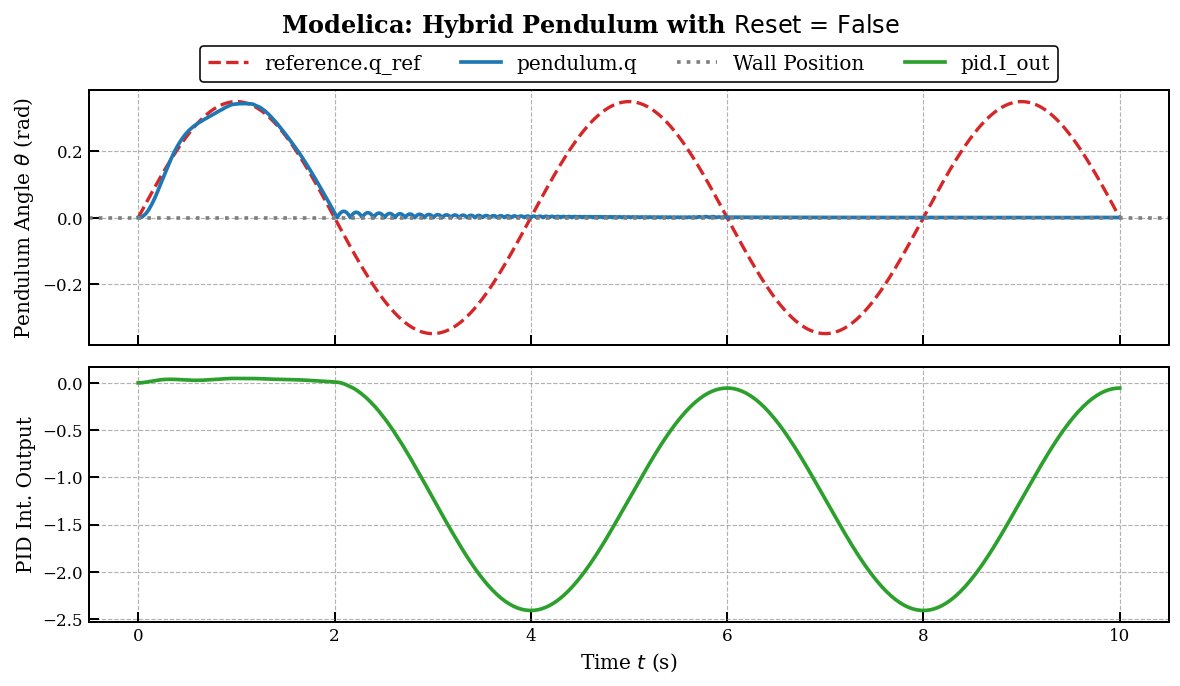

In [43]:
style_reset_true = {"color": "tab:green", "linestyle": "-", "linewidth": 2, "label": "Reset = true"}
style_reset_false = {
    "color": "tab:orange",
    "linestyle": "-",
    "linewidth": 2,
    "label": "Reset = false",
}

fig, axs = plt.subplots(ncols=1, nrows=2, sharex=True)
fig.set_size_inches(10, 6)

fig.suptitle(r"Modelica: Hybrid Pendulum with $\text{Reset = False}$", fontweight="bold", y=0.95)

(s1,) = axs[0].plot(
    results["false"]["time"],
    results["false"]["reference.q_ref"],
    label="reference.q_ref",
    color="tab:red",
    linestyle="--",
    linewidth=2,
)
(s2,) = axs[0].plot(
    results["false"]["time"], results["false"]["pendulum.q"], label="pendulum.q", color="tab:blue"
)
s3 = axs[0].axhline(y=0, color="tab:gray", linestyle=":", label="Wall Position")
axs[0].set_ylabel(r"Pendulum Angle $\theta$ (rad)")
axs[0].grid()

(s4,) = axs[1].plot(
    results["false"]["time"], results["false"]["pid.I_out"], color="tab:green", label="pid.I_out"
)
axs[1].set_xlabel(r"Time $t$ (s)")
axs[1].set_ylabel("PID Int. Output")
axs[1].grid()

handles = [s1, s2, s3, s4]
axs[0].legend(handles=handles, loc="center", bbox_to_anchor=(0.5, 1.1), ncols=4)

plt.tight_layout()
plt.savefig("../figures/Hybrid/Modelica_PID_Integrator_Reset_Falsesvg")

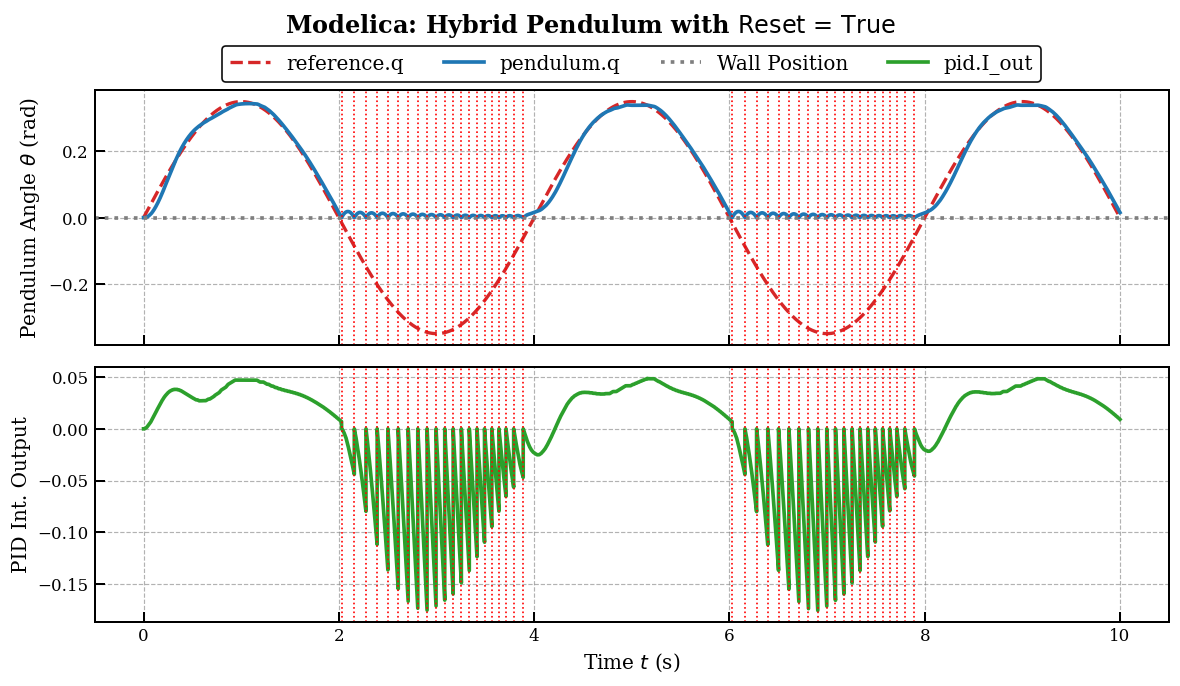

In [44]:
fig, axs = plt.subplots(ncols=1, nrows=2, sharex=True)
fig.set_size_inches(10, 6)

fig.suptitle(r"Modelica: Hybrid Pendulum with $\text{Reset = True}$", fontweight="bold", y=0.95)

(s1,) = axs[0].plot(
    results["false"]["time"],
    results["false"]["reference.q_ref"],
    label="reference.q",
    color="tab:red",
    linestyle="--",
    linewidth=2,
)
(s2,) = axs[0].plot(
    results["true"]["time"], results["true"]["pendulum.q"], color="tab:blue", label="pendulum.q"
)
s3 = axs[0].axhline(y=0, color="tab:gray", linestyle=":", label="Wall Position")
axs[0].set_ylabel(r"Pendulum Angle $\theta$ (rad)")
axs[0].grid()

(s4,) = axs[1].plot(
    results["true"]["time"], results["true"]["pid.I_out"], color="tab:green", label="pid.I_out"
)
axs[1].set_xlabel("Time $t$ (s)")
axs[1].set_ylabel("PID Int. Output")
axs[1].grid()

t_contact_style = {"color": "red", "linestyle": ":", "linewidth": 1}
i = 0
while i < len(results["true"]["contact_times"]):
    t = results["true"]["contact_times"][i]
    axs[0].axvline(t, **t_contact_style)
    axs[1].axvline(t, **t_contact_style)
    i += 2

handles = [s1, s2, s3, s4]
axs[0].legend(handles=handles, loc="center", bbox_to_anchor=(0.5, 1.1), ncols=4)

plt.tight_layout()
plt.savefig("../figures/Hybrid/Modelica_PID_Integrator_Reset_True.svg")